In [1]:
import pandas as pd 
from pathlib import Path
import json
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

In [2]:
ANALYSIS_DATA_PATH = Path.cwd() / "data" 
MAIN_DATA_PATH = Path.cwd().parent / "data"

In [3]:
def read_agws(path = ANALYSIS_DATA_PATH / "agws_2026-09-08.json"):
    payload = json.loads(path.read_text())
    df = pd.DataFrame(payload["data"])
    df["publishTime"] = pd.to_datetime(df["publishTime"], utc=True)
    df["startTime"] = pd.to_datetime(df["startTime"], utc=True)

    return df.sort_values(["settlementPeriod", "psrType"], ignore_index=True)

In [4]:
windfor_df = pd.read_csv(MAIN_DATA_PATH / "forecast_issues.csv")
windfor_df["publish_time_utc"] = pd.to_datetime(windfor_df["publish_time_utc"], utc=True)
windfor_df["target_start_utc"] = pd.to_datetime(windfor_df["target_start_utc"], utc=True)
day_ahead_windfor_df = windfor_df[windfor_df["publish_time_utc"] == pd.to_datetime("2026-09-07 16:30:00+00:00", utc=True)].copy()
day_ahead_windfor_df["target_start_london"] = day_ahead_windfor_df["target_start_utc"].dt.tz_convert("Europe/London")

fuelinst_df = pd.read_csv(MAIN_DATA_PATH / "fuelinst_wind_5min.csv")
fuelinst_df["publish_time_utc"] = pd.to_datetime(fuelinst_df["publish_time_utc"], utc=True)
fuelinst_df["start_time_utc"] = pd.to_datetime(fuelinst_df["start_time_utc"], utc=True)
hourly_fuelinst_df = fuelinst_df.groupby(fuelinst_df["start_time_utc"].dt.floor("h"), as_index=False).agg(generation_mw = ("generation_mw", "mean"), start_time_utc = ("start_time_utc", "min"))
hourly_fuelinst_df["start_time_london"] =  hourly_fuelinst_df["start_time_utc"].dt.tz_convert("Europe/London")

dgws_df = pd.read_csv(MAIN_DATA_PATH / "b1440_day_ahead.csv")
dgws_df["publish_time_utc"] = pd.to_datetime(dgws_df["publish_time_utc"], utc=True)
dgws_df["target_start_utc"] = pd.to_datetime(dgws_df["target_start_utc"], utc=True)
dgws_df = dgws_df[dgws_df["settlement_period"] >= 3]
total_wind_dgws_df = dgws_df[dgws_df["psr_type"].isin(["Wind Onshore", "Wind Offshore"])].groupby(["publish_time_utc", "target_start_utc"], as_index=False).agg(quantity_mw=("quantity_mw", "sum"))
total_wind_dgws_df["target_start_london"] = total_wind_dgws_df["target_start_utc"].dt.tz_convert("Europe/London")

agws_df = read_agws()
total_wind_agws_df = agws_df[agws_df["psrType"].isin(["Wind Onshore", "Wind Offshore"])].groupby(["publishTime", "startTime"], as_index=False).agg(quantity_mw=("quantity", "sum"))
total_wind_agws_df["startTimeLondon"] = total_wind_agws_df["startTime"].dt.tz_convert("Europe/London")
total_wind_agws_df = total_wind_agws_df[total_wind_agws_df["startTimeLondon"] >= total_wind_dgws_df["target_start_london"].min()]


# Timeseries Plots

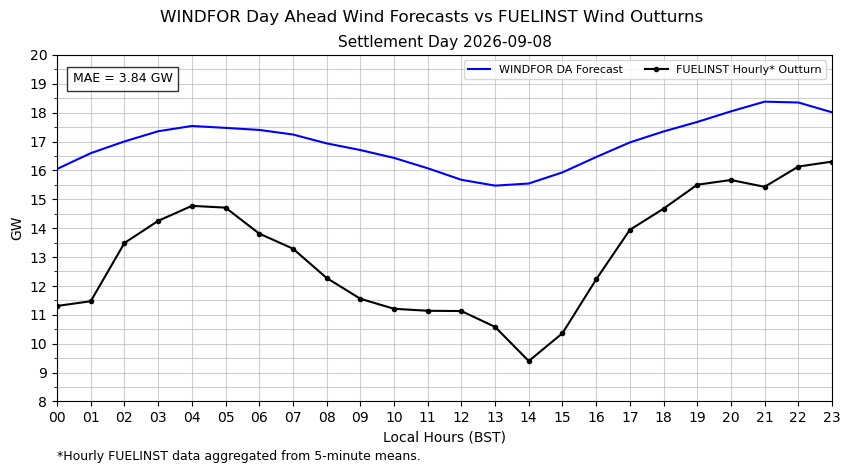

In [43]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.grid(visible=True, which="both", axis="both", alpha=0.6)
plt.rcParams["timezone"] = "Europe/London"

mae = np.mean(np.abs(day_ahead_windfor_df["forecast_mw"].values - hourly_fuelinst_df["generation_mw"].values)) / 1000 

ax.plot(day_ahead_windfor_df["target_start_london"], day_ahead_windfor_df["forecast_mw"] / 1000, label = "WINDFOR DA Forecast", color="blue")
ax.plot(hourly_fuelinst_df["start_time_london"], hourly_fuelinst_df["generation_mw"] / 1000, label = "FUELINST Hourly* Outturn", color="black", marker='o', markersize=3)

ax.set_yticks(np.arange(8, 21, 1))
ax.set_yticks(np.arange(8, 20.5, 0.5), minor=True)

ax.xaxis.set_major_locator(mdates.HourLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H"))
ax.margins(x=0)

fig.suptitle("WINDFOR Day Ahead Wind Forecasts vs FUELINST Wind Outturns", fontsize = 12)
ax.set_title("Settlement Day 2026-09-08", fontsize = 11)
ax.set_ylabel("GW")
ax.set_xlabel("Local Hours (BST)")

ax.annotate(
    "*Hourly FUELINST data aggregated from 5-minute means.",
    xy=(0, 0),
    xycoords="axes fraction",
    xytext=(0, -35),
    textcoords="offset points",
    ha="left",
    va="top",
    fontsize=9
)

ax.text(
    0.02, 0.95,
    f"MAE = {mae:.2f} GW",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9,
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="black")
)

ax.legend(ncol=2, fontsize=8)
plt.show()

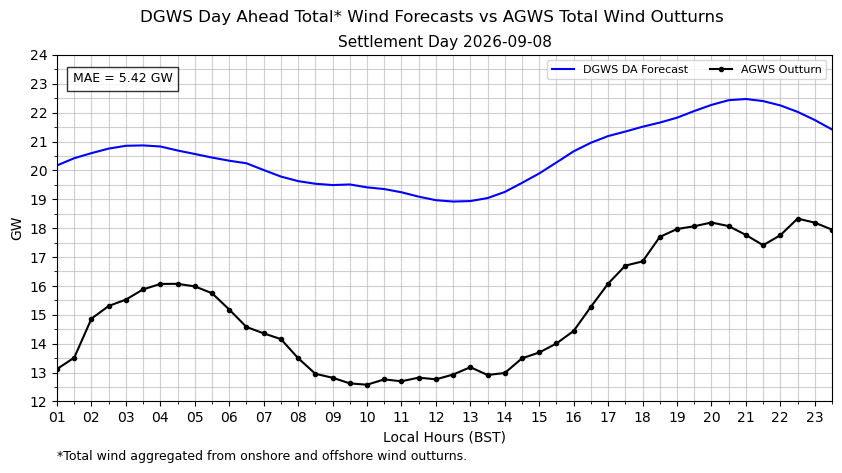

In [46]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.grid(visible=True, which="both", axis="both", alpha=0.6)
plt.rcParams["timezone"] = "Europe/London"

mae = np.mean(np.abs(total_wind_dgws_df["quantity_mw"].values - total_wind_agws_df["quantity_mw"].values)) / 1000 

ax.plot(total_wind_dgws_df["target_start_london"], total_wind_dgws_df["quantity_mw"] / 1000, label="DGWS DA Forecast", color="blue")
ax.plot(total_wind_agws_df["startTimeLondon"], total_wind_agws_df["quantity_mw"] / 1000, label = "AGWS Outturn", color="black", marker='o', markersize=3)

ax.set_yticks(np.arange(12, 25, 1))
ax.set_yticks(np.arange(12, 24.5, 0.5), minor=True)

ax.xaxis.set_major_locator(mdates.HourLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H"))
ax.xaxis.set_minor_locator(mdates.MinuteLocator(byminute=[30]))
ax.margins(x=0)

fig.suptitle("DGWS Day Ahead Total* Wind Forecasts vs AGWS Total Wind Outturns", fontsize=12)
ax.set_title("Settlement Day 2026-09-08", fontsize=11)

ax.set_ylabel("GW")
ax.set_xlabel("Local Hours (BST)")

ax.text(
    0.02, 0.95,
    f"MAE = {mae:.2f} GW",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9,
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="black")
)

ax.annotate(
    "*Total wind aggregated from onshore and offshore wind outturns.",
    xy=(0, 0),
    xycoords="axes fraction",
    xytext=(0, -35),
    textcoords="offset points",
    ha="left",
    va="top",
    fontsize=9
)

ax.legend(ncol=2, fontsize=8)
plt.show()

# WINDFOR Error Progression Heatmap

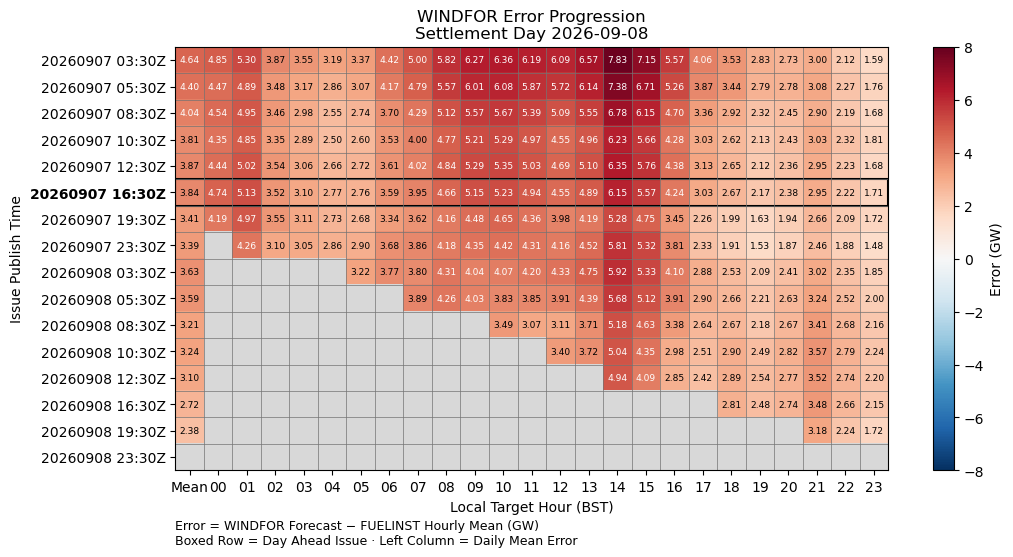

In [42]:
error = (windfor_df.pivot(index="publish_time_utc", columns="target_start_utc", values="forecast_mw")
         .sub(hourly_fuelinst_df.set_index("start_time_utc")["generation_mw"], axis=1) / 1000)
retro = error.index.to_numpy()[:, None] >= error.columns.to_numpy()[None, :]
error = error.mask(retro)

mean_error = error.mean(axis=1)  # per-issue daily mean over its unmasked forecast hours
display = np.column_stack([mean_error.to_numpy(), error.to_numpy()])

vmax = np.ceil(np.nanmax(np.abs(display)))
cmap = plt.get_cmap("RdBu_r").copy()
cmap.set_bad("0.85")

fig, ax = plt.subplots(figsize=(11.5, 5.5))
im = ax.imshow(display, aspect="auto", origin="upper", cmap=cmap,
               vmin=-vmax, vmax=vmax, interpolation="nearest")
ax.set_xticks(range(display.shape[1]),
              ["Mean"] + error.columns.tz_convert("Europe/London").strftime("%H").tolist())
ax.set_yticks(range(error.shape[0]), [f"{t:%Y%m%d %H:%M}Z" for t in error.index])
ax.set_xticks(np.arange(display.shape[1] + 1) - 0.5, minor=True)
ax.set_yticks(np.arange(error.shape[0] + 1) - 0.5, minor=True)
ax.grid(which="minor", color="0.45", linewidth=0.5)
ax.tick_params(which="minor", length=0)

da = list(error.index).index(pd.Timestamp("2026-09-07 16:30:00+00:00"))
ax.axhspan(da - 0.5, da + 0.5, fill=False, edgecolor="black", lw=1.5)
ax.get_yticklabels()[da].set_fontweight("bold")

for (i, j), value in np.ndenumerate(display):
    if np.isfinite(value):
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=6.5,
                color="white" if abs(value) > vmax / 2 else "black")

ax.set_title("WINDFOR Error Progression\nSettlement Day 2026-09-08")
ax.set_xlabel("Local Target Hour (BST)")
ax.set_ylabel("Issue Publish Time")

ax.annotate(
    "Error = WINDFOR Forecast − FUELINST Hourly Mean (GW)\nBoxed Row = Day Ahead Issue · Left Column = Daily Mean Error",
    xy=(0, 0),
    xycoords="axes fraction",
    xytext=(0, -35),
    textcoords="offset points",
    ha="left",
    va="top",
    fontsize=9
)
fig.colorbar(im, ax=ax, label="Error (GW)", shrink=1)
#fig.tight_layout()
plt.show()
